<a href="https://colab.research.google.com/github/elnazshokrollahi/ai-ml-refresh-journey/blob/main/transformers/transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

# ── The dot product measures similarity ─────────────────────────────
# Two vectors pointing in the same direction → high dot product
# Two vectors pointing in different directions → low/negative

a = np.array([1.0, 0.0, 0.0])   # points right
b = np.array([1.0, 0.0, 0.0])   # also points right
c = np.array([0.0, 1.0, 0.0])   # points up
d = np.array([-1.0, 0.0, 0.0])  # points left

print(f"a · b = {np.dot(a, b):.1f}  ← identical direction, max similarity")
print(f"a · c = {np.dot(a, c):.1f}  ← perpendicular, no similarity")
print(f"a · d = {np.dot(a, d):.1f}  ← opposite, negative similarity")

# In attention:
# Q[i] · K[j] = how much token i's QUERY matches token j's KEY
# High value = token i should pay a lot of attention to token j

a · b = 1.0  ← identical direction, max similarity
a · c = 0.0  ← perpendicular, no similarity
a · d = -1.0  ← opposite, negative similarity


In [ ]:
torch.manual_seed(42)

# Pretend these are our 4 token embeddings after the embedding layer
# "patient  missed  MRI  appointment"
seq_len = 4
d_model = 8

X = torch.randn(seq_len, d_model)
# Shape: (4, 8) — 4 tokens, each 8-dimensional

print("Input X (token embeddings):")
print(X.round(decimals=2))
print(f"Shape: {X.shape}\n")

Input X (token embeddings):
tensor([[ 1.9300,  1.4900,  0.9000, -2.1100,  0.6800, -1.2300, -0.0400, -1.6000],
        [-0.7500,  1.6500, -0.3900, -1.4000, -0.7300, -0.5600, -0.7700,  0.7600],
        [ 1.6400, -0.1600, -0.5000,  0.4400, -0.7600,  1.0800,  0.8000,  1.6800],
        [ 1.2800,  1.3000,  0.6100,  1.3300, -0.2300,  0.0400, -0.2500,  0.8600]])
Shape: torch.Size([4, 8])



In [ ]:
d_k = 4
d_v = 4

In [ ]:
W_Q = torch.randn(d_model, d_k)
W_K = torch.randn(d_model, d_k)
W_V = torch.randn(d_model, d_v)

print(f"W_Q shape: {W_Q.shape}  — projects d_model={d_model} → d_k={d_k}")
print(f"W_K shape: {W_K.shape}  — projects d_model={d_model} → d_k={d_k}")
print(f"W_V shape: {W_V.shape}  — projects d_model={d_model} → d_v={d_v}\n")

W_Q shape: torch.Size([8, 4])  — projects d_model=8 → d_k=4
W_K shape: torch.Size([8, 4])  — projects d_model=8 → d_k=4
W_V shape: torch.Size([8, 4])  — projects d_model=8 → d_v=4



In [ ]:
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print(f"W_Q shape: {W_Q.shape}  — projects d_model={d_model} → d_k={d_k}")
print(f"W_K shape: {W_K.shape}  — projects d_model={d_model} → d_k={d_k}")
print(f"W_V shape: {W_V.shape}  — projects d_model={d_model} → d_v={d_v}\n")

W_Q shape: torch.Size([8, 4])  — projects d_model=8 → d_k=4
W_K shape: torch.Size([8, 4])  — projects d_model=8 → d_k=4
W_V shape: torch.Size([8, 4])  — projects d_model=8 → d_v=4



In [ ]:
scores_raw = Q @ K.T

print("Raw attention scores (Q @ K^T):")
print(scores_raw.round(decimals=2))
print(f"\nShape: {scores_raw.shape}")
print(f"\nscores[i][j] = how much token i attends to token j")
print(f"scores[0][2] = {scores_raw[0][2]:.2f}  ← 'patient' → 'MRI'")
print(f"scores[3][0] = {scores_raw[3][0]:.2f}  ← 'appointment' → 'patient'")

Raw attention scores (Q @ K^T):
tensor([[-21.8500,  22.3100,  34.1100,   5.9500],
        [ 18.5300, -18.0300,  18.3700,   6.7700],
        [  8.1200,  16.0600, -16.8700,   3.2000],
        [ -6.8400,   7.4600, -21.7400,  -4.2900]])

Shape: torch.Size([4, 4])

scores[i][j] = how much token i attends to token j
scores[0][2] = 34.11  ← 'patient' → 'MRI'
scores[3][0] = -6.84  ← 'appointment' → 'patient'


In [ ]:
large_scores = torch.tensor([10.0, 11.0, 10.5, 9.8])
small_scores = torch.tensor([1.0,  1.1,  1.05, 0.98])

print("Without scaling (large scores):")
print(F.softmax(large_scores, dim=0).round(decimals=4))
# → [0.07, 0.57, 0.27, 0.08]  almost one-hot, kills gradient flow

print("\nWith scaling (small scores):")
print(F.softmax(small_scores, dim=0).round(decimals=4))
# → [0.23, 0.26, 0.25, 0.22]  softer, gradients flow better

Without scaling (large scores):
tensor([0.1617, 0.4394, 0.2665, 0.1324])

With scaling (small scores):
tensor([0.2417, 0.2672, 0.2541, 0.2370])


In [ ]:
scores_scaled = scores_raw / math.sqrt(d_k)

print(f"\nScaled scores (÷ √{d_k} = ÷ {math.sqrt(d_k):.2f}):")
print(scores_scaled.round(decimals=2))


Scaled scores (÷ √4 = ÷ 2.00):
tensor([[-10.9300,  11.1600,  17.0600,   2.9800],
        [  9.2600,  -9.0100,   9.1900,   3.3900],
        [  4.0600,   8.0300,  -8.4400,   1.6000],
        [ -3.4200,   3.7300, -10.8700,  -2.1400]])


In [ ]:
# Create upper triangular mask
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
print("Causal mask (True = block this position):")
print(mask)

#        patient  missed  MRI  appointment
# patient  [False,  True,  True,  True ]   ← patient only sees itself
# missed   [False, False,  True,  True ]   ← missed sees patient + itself
# MRI      [False, False, False,  True ]
# appoint  [False, False, False, False]    ← sees all previous tokens

scores_masked = scores_scaled.masked_fill(mask, float('-inf'))
print("\nScores after masking (-inf will become 0 after softmax):")
print(scores_masked.round(decimals=2))


Causal mask (True = block this position):
tensor([[False,  True,  True,  True],
        [False, False,  True,  True],
        [False, False, False,  True],
        [False, False, False, False]])

Scores after masking (-inf will become 0 after softmax):
tensor([[-10.9300,     -inf,     -inf,     -inf],
        [  9.2600,  -9.0100,     -inf,     -inf],
        [  4.0600,   8.0300,  -8.4400,     -inf],
        [ -3.4200,   3.7300, -10.8700,  -2.1400]])


In [ ]:
attention_weights = F.softmax(scores_masked, dim=-1)
# dim=-1 means softmax over the LAST dimension (the key dimension)
# so each query token's weights sum to 1

print("Attention weights (each row sums to 1):")
print(attention_weights.round(decimals=3))
print(f"\nRow sums: {attention_weights.sum(dim=-1).round(decimals=3)}")


Attention weights (each row sums to 1):
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000],
        [0.0180, 0.9820, 0.0000, 0.0000],
        [0.0010, 0.9960, 0.0000, 0.0030]])

Row sums: tensor([1., 1., 1., 1.])


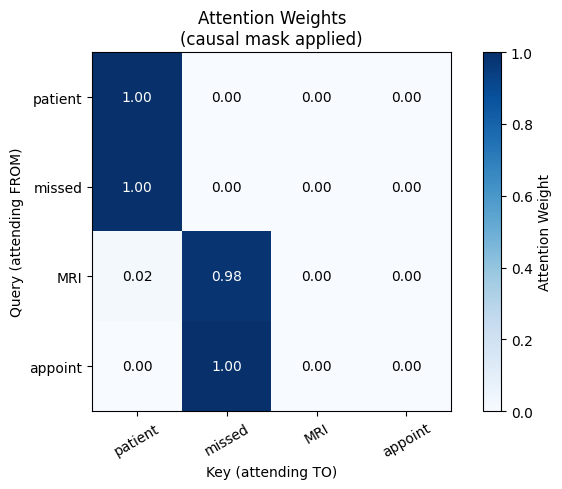

In [ ]:
# Visualize
tokens = ["patient", "missed", "MRI", "appoint"]
plt.figure(figsize=(7, 5))
plt.imshow(attention_weights.detach().numpy(), cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label='Attention Weight')
plt.xticks(range(4), tokens, rotation=30)
plt.yticks(range(4), tokens)
plt.xlabel('Key (attending TO)')
plt.ylabel('Query (attending FROM)')
plt.title('Attention Weights\n(causal mask applied)')
for i in range(4):
    for j in range(4):
        val = attention_weights[i,j].item()
        plt.text(j, i, f'{val:.2f}', ha='center', va='center',
                 color='white' if val > 0.5 else 'black', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
output = attention_weights @ V   # (4, 4) @ (4, 4) = (4, 4)

print("Final attention output:")
print(output.round(decimals=3))
print(f"\nShape: {output.shape}")


Final attention output:
tensor([[-8.2490, -0.9330,  2.3790, -0.8350],
        [-8.2490, -0.9330,  2.3790, -0.8350],
        [ 3.9150, -1.3820,  2.1180, -1.3150],
        [ 4.1200, -1.3760,  2.1160, -1.3220]])

Shape: torch.Size([4, 4])


In [ ]:
# Full pipeline summary:
print("\n=== FULL ATTENTION PIPELINE ===")
print(f"Input X:              {X.shape}")
print(f"Queries Q = X @ W_Q:  {Q.shape}")
print(f"Keys    K = X @ W_K:  {K.shape}")
print(f"Values  V = X @ W_V:  {V.shape}")
print(f"Scores = Q @ K^T:     {scores_raw.shape}")
print(f"Scaled  = / sqrt(dk): {scores_scaled.shape}")
print(f"Weights = softmax:    {attention_weights.shape}")
print(f"Output  = W @ V:      {output.shape}")


=== FULL ATTENTION PIPELINE ===
Input X:              torch.Size([4, 8])
Queries Q = X @ W_Q:  torch.Size([4, 4])
Keys    K = X @ W_K:  torch.Size([4, 4])
Values  V = X @ W_V:  torch.Size([4, 4])
Scores = Q @ K^T:     torch.Size([4, 4])
Scaled  = / sqrt(dk): torch.Size([4, 4])
Weights = softmax:    torch.Size([4, 4])
Output  = W @ V:      torch.Size([4, 4])


## Multi Heat Attention: How Head Specialize

In [ ]:
class MultiHeadAttentionDetailed (nn.Module):
  def __init__(self, d_model=512, num_heads=8):
    super().__init__()
    assert d_model % num_heads == 0

    self.d_model = d_model
    self.num_heads = num_heads
    self.d_k = d_k

    self.W_Q = nn.Linear(d_model, d_model, bias = False)
    self.W_K = nn.Linear(d_model, d_model, bias = False)
    self.W_V = nn.Linear(d_model, d_model, bias = False)
    self.W_O = nn.Linear(d_model, d_model, bias = False)

    self.droupout = nn.Dropout(0.1)

In [ ]:
def split_into_heads(self, x, batch_size, seq_len):

  x = x.view(batch_size, seq_len, self.num_heads, self.d_k)

  x = x.transpose(1,2)

  return x

  def scaled_dot_product_attention(self, Q, K, V, mask = None):

    scores = torch.matmul(Q, K.transpose(-2, -1))
    scores = scores/ math.sqrt(self.d_k)

    if mask is not None:
      scores = scores.masked_fill(mask == 0, float('-inf'))


    attention_weights = F.softmax(scores, dim=1)
    attention_weights = self.droupout(attention_weights)


    output = torch.matmul(attention_weights, V)

    return output, attention_weights


## Forward Pass

In [ ]:
def forward (self, x, mask=None):

  batch_size, seq_len, _ = x.shape

  Q = self.W_Q(x)
  K = self.W_K(x)
  V = self.W_V(x)

  Q = self.split_into_heads(Q, batch_size, seq_len)
  K = self.split_into_heads(K, batch_size, seq_len)
  V = self.split_into_heads(V, batch_size, seq_len)

  atten_output, atten_weights = self.scaled_dot_product_attention(Q, K, V, mask)

  atten_output = atten_output.transpose(1,2)

  atten_output = atten_output.contiguous()

  atten_output = atten_output.view(batch_size, seq_len, self.d_model)

  output = self.W_O(atten_output)

  return output, atten_weights


### Transformer From Scratch


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

token_A = torch.tensor([1.0, 0.5, 0.2, 0.8])   # "patient"
token_B = torch.tensor([0.9, 0.4, 0.3, 0.7])   # "missed"
token_C = torch.tensor([0.1, 0.9, 0.8, 0.1])   # "the"

score_AB = torch.dot(token_A, token_B)
score_AC = torch.dot(token_A, token_C)

print(f"Score A→B: {score_AB:.3f}   ('patient' → 'missed')")
print(f"Score A→C: {score_AC:.3f}   ('patient' → 'the')")
print(f"\n'patient' is more similar to 'missed' than to 'the'")
print(f"So it will pay more attention to 'missed'")


Score A→B: 1.720   ('patient' → 'missed')
Score A→C: 0.790   ('patient' → 'the')

'patient' is more similar to 'missed' than to 'the'
So it will pay more attention to 'missed'


In [ ]:
# STEP 2 - One Token attending to All Others

tokens = torch.stack([token_A, token_B, token_C])

scores = tokens @ token_A

print(f"Raw Scores: {scores.round(decimals=3)}")

weights = F.softmax (scores, dim=0)

print(f"Weights: {weights.round(decimals=3)}")
print(f"Sum:     {weights.sum():.1f}")

output_A = (weights.unsqueeze(1) * tokens).sum(dim=0)


print(f"\nOriginal token_A: {token_A.round(decimals=3)}")
print(f"After attention:  {output_A.round(decimals=3)}")
print(f"\ntoken_A now contains a blend of all tokens,")
print(f"weighted by how much it attended to each one")

Raw Scores: tensor([1.9300, 1.7200, 0.7900])
Weights: tensor([0.4690, 0.3800, 0.1500])
Sum:     1.0

Original token_A: tensor([1.0000, 0.5000, 0.2000, 0.8000])
After attention:  tensor([0.8270, 0.5220, 0.3280, 0.6570])

token_A now contains a blend of all tokens,
weighted by how much it attended to each one


In [ ]:
#Step 3 The Q, K ,V Seperation

torch.manual_seed(42)
d_model = 4
d_k = 4

W_Q = nn.Linear(d_model, d_k, bias = False)
W_K = nn.Linear(d_model, d_k, bias = False)
W_V = nn.Linear(d_model, d_k, bias = False)

X = torch.stack([ token_A, token_B, token_C])

Q = W_Q(X)
K = W_K(X)
V = W_V(X)

print(f"X shape: {X.shape}  (3 tokens, 4 dims each)")
print(f"Q shape: {Q.shape}  — same, different projection")
print(f"K shape: {K.shape}  — same, different projection")
print(f"V shape: {V.shape}  — same, different projection")

scores = Q @ K.T
scores = scores / math.sqrt(d_k)

weights = F.softmax (scores, dim=-1)

output = weights @ V

print(f"\nAttention weights:\n{weights.round(decimals=3)}")
print(f"\nOutput shape: {output.shape}  ← same as input, but context-enriched")

X shape: torch.Size([3, 4])  (3 tokens, 4 dims each)
Q shape: torch.Size([3, 4])  — same, different projection
K shape: torch.Size([3, 4])  — same, different projection
V shape: torch.Size([3, 4])  — same, different projection

Attention weights:
tensor([[0.3460, 0.3470, 0.3070],
        [0.3400, 0.3440, 0.3160],
        [0.3360, 0.3390, 0.3250]], grad_fn=<RoundBackward1>)

Output shape: torch.Size([3, 4])  ← same as input, but context-enriched


In [ ]:
#Step 4 The Scaling

d_k = 64

q = torch.randn(d_k)
k = torch.randn(d_k)

raw_score = torch.dot(q, k)
scaled_score = raw_score / math.sqrt(d_k)


print(f"d_k = {d_k}")
print(f"Raw dot product:    {raw_score:.2f}   ← grows with d_k")
print(f"Scaled dot product: {scaled_score:.2f}   ← stays manageable")

# Show the softmax effect
example_scores_unscaled = torch.tensor([8.0, 7.5, 7.8, 7.2, 7.9])
example_scores_scaled   = example_scores_unscaled / math.sqrt(d_k)

print(f"\nSoftmax without scaling: {F.softmax(example_scores_unscaled, dim=0).round(decimals=3)}")
print(f"Softmax with scaling:    {F.softmax(example_scores_scaled, dim=0).round(decimals=3)}")
print(f"\nWithout: near one-hot → only one token gets attention → poor learning")
print(f"With:    spread out  → multiple tokens attended → better gradients")

d_k = 64
Raw dot product:    9.50   ← grows with d_k
Scaled dot product: 1.19   ← stays manageable

Softmax without scaling: tensor([0.2650, 0.1600, 0.2170, 0.1190, 0.2390])
Softmax with scaling:    tensor([0.2080, 0.1950, 0.2030, 0.1880, 0.2050])

Without: near one-hot → only one token gets attention → poor learning
With:    spread out  → multiple tokens attended → better gradients


In [ ]:
# Step 5 - Full Single Head Attention


def single_head_attention (X, W_Q, W_K, W_V, mask = None):

  d_k = W_Q.weight.shape[0]

  Q = W_Q(X)
  K = W_K(X)
  V = W_V(X)

  scores = Q @ K.T
  scores = scores/ math.sqrt(d_k)

  if mask is not None:
    scores =scores.masked_fill(mask, float('-inf'))


  weights = F.softmax(scores, dim= -1)
  output = weights @ V

  return output, weights

# lets test it
torch.manual_seed(0)
seq_len, d_model, d_k = 5, 8, 8

X    = torch.randn(seq_len, d_model)
W_Q  = nn.Linear(d_model, d_k, bias=False)
W_K  = nn.Linear(d_model, d_k, bias=False)
W_V  = nn.Linear(d_model, d_k, bias=False)

out, w = single_head_attention(X, W_Q, W_K, W_V)

print(f"Input shape:            {X.shape}")
print(f"Output shape:           {out.shape}   ← same")
print(f"Attention weight shape: {w.shape}     ← (seq × seq)")
print(f"\nWeights row sums: {w.sum(dim=-1).round(decimals=3)}")
print(f"Each row sums to 1.0 → probability distribution")

Input shape:            torch.Size([5, 8])
Output shape:           torch.Size([5, 8])   ← same
Attention weight shape: torch.Size([5, 5])     ← (seq × seq)

Weights row sums: tensor([1., 1., 1., 1., 1.], grad_fn=<RoundBackward1>)
Each row sums to 1.0 → probability distribution


In [ ]:
# Step 6  - Multi_Head Attention


class MultiHeadAttention (nn.Module):

  def __init__(self, d_model, num_heads):
    super().__init__()
    assert d_model % num_heads == 0

    self.d_model = d_model
    self.num_heads = num_heads
    self.d_k = d_model // num_heads

    self.W_Q = nn.Linear(d_model, d_model, bias = False)
    self.W_K = nn.Linear(d_model, d_model, bias = False)
    self.W_V = nn.Linear(d_model, d_model, bias = False)
    self.W_O = nn.Linear(d_model, d_model, bias = False)
  def forward(self, x, mask= None):

    B, T, _ = x.shape
    Q = self.W_Q(x)
    K = self.W_K(x)
    V = self.W_V(x)

    def split(t):
      return t.view(B, T, self.num_heads, self.d_k).transpose(1,2)


    Q, K, V = split(Q), split(K), split(V)

    scores = Q . K.transpose(-2, -1) / math.sqrt(self.d_k)

    if mask is not None:
      scores = scores.masked_fill(mask, float('-inf'))

    weights = F.softmax(scores, dim=1)

    output = weights @ V

    output = output.transpose(1,2).contiguous
    output = output.view(B,T, self.d_model)

    output = self.W_O(output)

    return output, weights


In [ ]:
x = torch.tensor([[1., 2.], [3., 4.]])
y = torch.rand(2, 2) # Random tensor
print("Tensor x:\n", x)
print("Tensor y:\n", y)

# Tensor operations (Example: Matrix Multiplication)
z = torch.matmul(x, y)
print("Matrix Multiplication (x @ y):\n", z)

# Indexing
print("Element at [0, 1] of z:", z[0, 1].item()) # .item() gets Python number from scalar tensor

# Tensor shapes
print("Shape of x:", x.shape)
print("Shape of z:", z.shape)

# Reshaping (view) - often needed in Transformers
# Example: Flatten the tensor z
flat_z = z.view(-1) # -1 infers the size
print("Flattened z:", flat_z)

Tensor x:
 tensor([[1., 2.],
        [3., 4.]])
Tensor y:
 tensor([[0.5069, 0.4150],
        [0.2367, 0.5661]])
Matrix Multiplication (x @ y):
 tensor([[0.9802, 1.5472],
        [2.4673, 3.5093]])
Element at [0, 1] of z: 1.547162652015686
Shape of x: torch.Size([2, 2])
Shape of z: torch.Size([2, 2])
Flattened z: tensor([0.9802, 1.5472, 2.4673, 3.5093])


In [ ]:
print("Shape of flattened z:", flat_z.shape)


Shape of flattened z: torch.Size([4])


In [ ]:
reshaped_z = flat_z.view(2, 2)
print("Reshaped z:\n", reshaped_z)

Reshaped z:
 tensor([[0.9802, 1.5472],
        [2.4673, 3.5093]])


In [ ]:
d_in = 4 # Input dimension
d_out = 8 # Output dimension
linear_layer = nn.Linear(d_in, d_out)
print("Linear Layer:", linear_layer)

Linear Layer: Linear(in_features=4, out_features=8, bias=True)


In [ ]:
# --- Autograd Basics ---
print("\n--- Autograd Basics ---")
# Tensors track gradients if requires_grad=True
a = torch.tensor([[1., 2.], [3., 4.]], requires_grad=True)
b = torch.tensor([[5., 6.], [7., 8.]], requires_grad=True)
c = a * b
d = c.mean() # Calculate a scalar value

print("Tensor a:", a)
print("Tensor d (scalar output):", d)


--- Autograd Basics ---
Tensor a: tensor([[1., 2.],
        [3., 4.]], requires_grad=True)
Tensor d (scalar output): tensor(17.5000, grad_fn=<MeanBackward0>)


In [ ]:
# Implementing the input embeddings:

class InputEmbeddings(nn.Module):

  def __init__ (self, d_model, vocab_size):

    super().__init__()
    self.d_model = d_model
    self.vocab_size = vocab_size
    self.embedding = nn.Embedding(vocab_size, d_model)

  def forward(self,x):
    return self.embedding(x) * math.sqrt(self.d_model)



In [ ]:
import torch
import torch.nn as nn
import math

def scaled_dot_product_attention (query, key, value, mask=None, dropout: nn.Dropout = None):

  d_k = query.shape[-1]

  attention_scores = torch.matmul(query, key.transpose(-2,-1))
  attention_scores = attention_scores / math.sqrt(d_k)

  if mask is not None:
    attention_scores = attention_scores.masked_fill(mask, float('-inf'))

  attention_weights = torch.softmax(attention_scores, dim=-1)

  if dropout is not None:
    attention_weights = dropout(attention_weights)

  output = torch.matmul(attention_weights, value)

  return output, attention_weights







In [ ]:
##MultiHead Attention Mechanism

import torch
import torch.nn as nn
import math

class MultiHeadAttention (nn.Module):
  def __init__(self, d_model, num_heads, dropout):
    super().__init__()
    assert d_model % num_heads == 0
    self.d_model = d_model
    self.num_heads = num_heads
    self.d_k = d_model//num_heads

    self.W_Q = nn.Linear(d_model, d_model)
    self.W_K = nn.Linear(d_model, d_model)
    self.W_V = nn.Linear(d_model, d_model)
    self.W_O = nn.Linear(d_model, d_model)

    self.dropout = nn.Dropout(dropout)

    self.attention_weights = 0

  def forward (self, x, mask = None):

    B, T, _ = x.shape

    Q = self.W_Q(x)
    K = self.W_K(x)
    V = self.W_V(x)

    def split(t):
      return t.view(B, T, self.num_heads, self.d_k).transpose(1,2)

    Q, K, V = split(Q), split(K), split(V)

    output, self.attention_weights = scaled_dot_product_attention(Q, K, V, mask, self.dropout)

    output = output.transpose(1,2).contiguous()
    output = output.view(B, T, self.d_model)

    output = self.W_O(output)

    return output


In [ ]:
# implementing the layer normalization

import torch
import torch.nn as nn
import math

class LayerNormalization(nn.Module):

  def __init__(self, feature, eps=1e-5):

    super().__init__()
    self.eps = eps

    self.gamma = nn.Parameter(torch.ones(feature))
    self.beta = nn.Parameter(torch.zeros(feature))

    def forward (self, x):

      mean = x.mean(dim=-1, keepdim=True)
      std = x.std(dim=-1, keepdim=True)

      normalized_x = (x - mean) / torch.sqrt(std**2 +self.eps)

      output = self.gamma * normalized_x + self.beta

      return output




In [ ]:
## Implementing the FFN

import torch
import torch.nn as nn

class PositionwiseFeedForward(nn.Module):

  def __init__(self, d_model, d_ff, dropout):

    super().__init__()

    self.linear1 = nn.Linear(d_model, d_ff)
    self.dropout = nn.Dropout(dropout)

    self.activation = nn.Relu()
    self.linear2 = nn.Linear(d_-ff, d_model)

  def forward (self, x):

    x = self.linear1(x)
    x = self.activation(x)
    x = self.dropout(x)
    x = self.linear2(x)
    return x


In [ ]:
# Implement the residual coonections

import torch
import torch.nn as nn

class ResidualConnection(nn.Module):

  def __init__(self, features, dropout):

    super().__init__()
    self.dropout = nn.Dropout(dropout)
    self.norm = LayerNormalization(features)

    def forward (self, x, sublayer):

      sublayer_output = sublayer(x)
      return self.norm(x +self.dropout(sublayer_output))

In [ ]:
## Implement the Encoder Block

import torch
import torch.nn as nn

class EncoderBlock(nn.Module):

  def __init__(self, features, self_attention_block, feed_forward_block, dropout):

    super().__init__()
    self.self_attention_block = self_attention_block
    self.feed_forward_block = feed_forward_block
    self.residual_connections = nn.ModuleList([ResidualConnection(feature,dropout) for _ in range(2)])

  def forward(self, x, src_mask):

    x = self.residual_connections[0](x, lambda x_res: self.self_attention_block(x_res, x_res, x_res, src_mask))

    x = self.residual_connections[1](x, self.feed_forward_block)

    return x


In [ ]:
## Implementing the Decorder Block


import torch
import torch.nn as nn

class DecoderBlock(nn.Module):

  def __init__(self, features, self_attention_block, cross_attention_block, feed_forward_block, dropout):
    super().__init__()
    self.self_attention_block = self_attention_block
    self.cross_attention_block = cross_attention_block
    self.feed_forward_block = feed_forward_block
    self.residual_connections = nn.ModuleList ([ResidualConnection(features, dropout) for _ in range(3)])

  def forward (self, x:torch.Tensor, encoder_output: torch.Tensor, src_mask: torch.Tensor, tgt_mask: torch.Tensor):

    x = self.residual_connections[0](x, lambda x_res: self.self_attention_block(x_res, x_res, x_res, tgt_mask))

    x = self.residual_connections[1](x, lambda x_res: self.cross_attention_block(x_res, encoder_output, encoder_output, src_mask))

    x = self.residual_connections[2](x, self.feed_forward_block)

    return x

In [ ]:
# implementing the Decoder stack

import torch
import torch.nn as nn

class Decorder(nn.Module):

  def __init__(self, features, layers):
    super().__init__()

    self.layers = layers
    self.norm = LayerNormalization(features)

  def forward (self, x:torch.Tensor, encoder_output: torch.Tensor, src_mask: torch.Tensor, tgt_mask: torch.Tensor):

    for layer in self.layers:
      x = layer (x,encoder_output, src_mask, tgt_mask)

    return self.norm(x)

## Projection Layer


In [ ]:
import torch
import torch.nn as nn

class ProjectionLayer(nn.Module):

  def __init__(self, d_model, vocab_size):

    super().__init__()


  def forward(self, x:torch.Tensor):

    return self.proj(x)